# Extended Data Fig. 1

The remaining ONT panels: agreement by read depth for each arm on its own, and what the
agent consumed against the compute it set off.

The cost chart is `scripts/paper/make_cost_panel.py`, inlined below.

In [1]:
import sys; sys.path.insert(0, "../scripts"); sys.path.insert(0, "../scripts/paper")
from pathlib import Path
from nbkit import setup, paper_py, paper_r, run_r_source, harvest, show, have_r_package, DATA

OUT = setup("../figures/notebook")
print("panels will be written to", OUT)

# %%R cells below run R natively in this kernel through rpy2, so the R panels are R code
# in the notebook rather than a string that gets written to a file.
%load_ext rpy2.ipython

panels will be written to ./figures/notebook


$HOME_DIR/conda/envs/lvfig_r/lib/R/bin/exec/R: $HOME/.conda/envs/r_arrow_env/lib/libpcre2-8.so.0: no version information available (required by $HOME/.conda/pkgs/r-base-4.4.3-h835929b_7/lib/R/bin/exec/../../lib/libR.so)


## a - agreement with the bisulfite reference, each arm separately

font: DejaVu Sans
{
  "font_used": "DejaVu Sans",
  "human": "human_upstream",
  "agents": [
    "agent_mcp_prompt"
  ],
  "tss_profile": {
    "agent_mcp_prompt": {
      "n_bins": 80,
      "pearson_r": 1.0,
      "rms_difference": 2.24e-06,
      "max_abs_difference": 1e-05
    }
  },
  "wgbs_by_coverage": {
    "agent_mcp_prompt": {
      "bins": 7,
      "max_abs_PCC_difference": 2.92e-06
    }
  }
}
panels -> ./data/runs/figure2/panels
12 panels collected


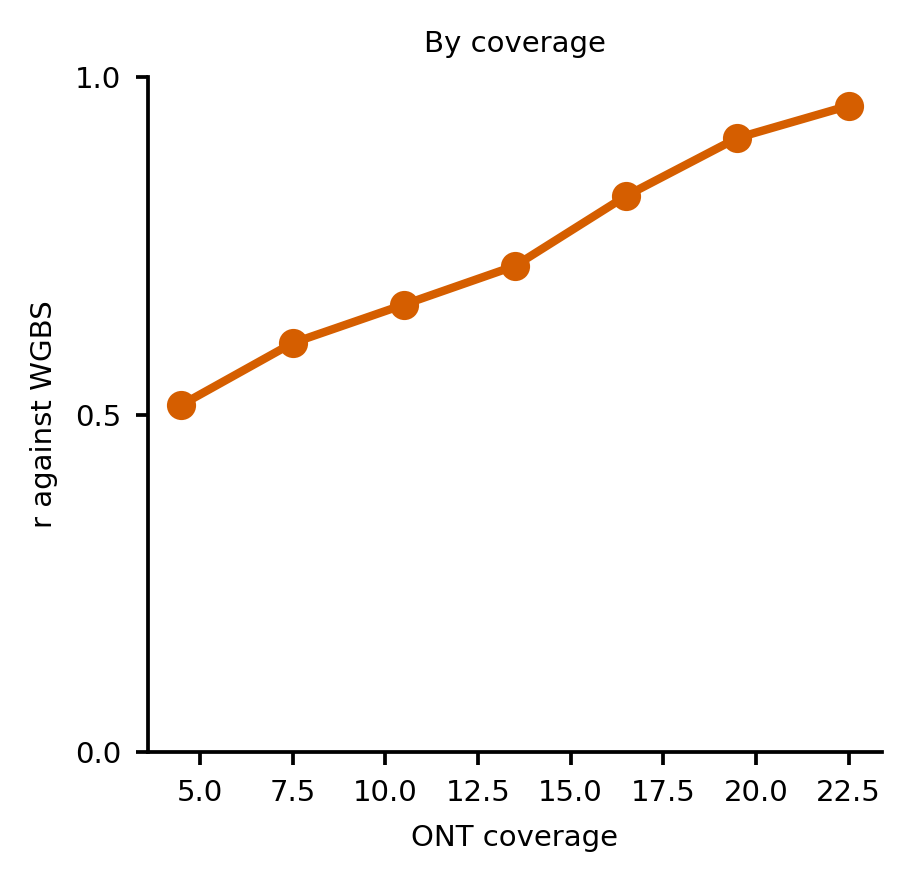

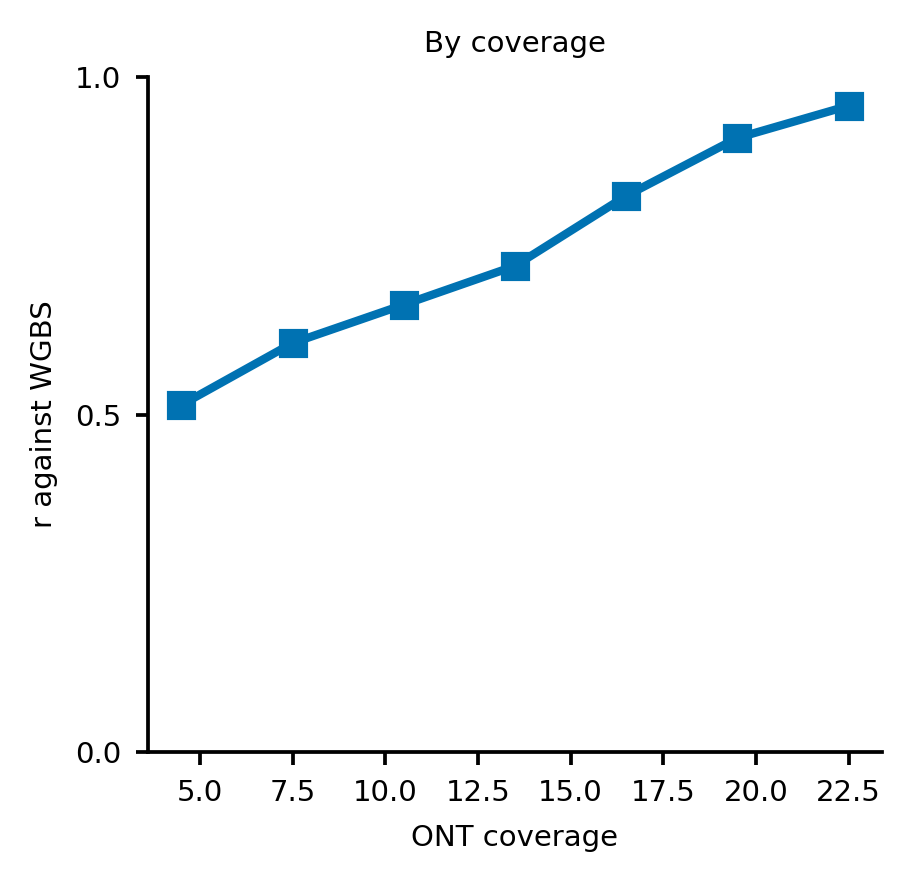

In [2]:
# scripts/paper/make_panels.py, inlined. sys.argv is what the paper passes it.
import sys
sys.argv = ['make_panels.py', 'figure2', 'human_upstream', 'agent_mcp_prompt']
__file__ = "../scripts/paper/make_panels.py"

"""Draw the data panels of New Figure 2 and New Figure 3 from the evaluation records.

One plotting function per panel type serves every arm, so anything visible is a difference
in the data and not in the drawing. Human on the left, agent on the right, without
exception. Each panel is written as PDF and PNG, and the numbers behind it as CSV.

Usage: 50_make_panels.py figure2|figure3 <human_label> <agent_label> [more agent labels]
"""
from __future__ import annotations

import csv
import json
import sys
import os
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import font_manager

sys.path.insert(0, str(Path(__file__).resolve().parent))
import panel_style

RUN = Path(os.environ.get("LV_RUN", "/project2/sli68423_1316/projects/long_verse/results/2026_09_25_longverse_agent_benchmark"))
EVAL = RUN / "evaluation"
FONT_DIR = Path(os.environ.get("LV_FONTS", "/project2/sli68423_1316/users/yang/software/fonts"))

FONT_USED = "DejaVu Sans"
for t in ("arial.ttf", "arialbd.ttf", "ariali.ttf"):
    if (FONT_DIR / t).is_file():
        font_manager.fontManager.addfont(str(FONT_DIR / t))
if (FONT_DIR / "arial.ttf").is_file():
    FONT_USED = "Arial"
panel_style.apply(plt, FONT_USED)
HUMAN_C, AGENT_C = "#D55E00", "#0072B2"
OTHER_C = ["#009E73", "#CC79A7", "#56B4E9"]


def load(label: str) -> dict:
    p = EVAL / f"{label}.json"
    if not p.is_file():
        raise SystemExit(f"missing evaluation record: {p}")
    return json.load(open(p))


def pearson(xs, ys):
    n = len(xs)
    mx, my = sum(xs) / n, sum(ys) / n
    sx = sum((v - mx) ** 2 for v in xs) ** 0.5
    sy = sum((v - my) ** 2 for v in ys) ** 0.5
    return (sum((xs[i] - mx) * (ys[i] - my) for i in range(n)) / (sx * sy)) if sx and sy else float("nan")


def prof(rec: dict) -> tuple[list, list]:
    m = rec["measurements"].get("tss_profile")
    if not m or not m.get("ok"):
        return [], []
    pts = m["payload"]["profile"]
    return [p["position_bp"] for p in pts], [p["mean_methylation"] for p in pts]


def draw_profile(ax, x, y, colour, title, compact: bool = False):
    """`compact` is for the single-arm panels, which are small and carry 12 pt type.

    Five tick labels and the words "mean CpG methylation" do not fit beside a 2.5 inch
    axis at 12 pt; three ticks and "CpG methylation" do. Nothing is shortened on the
    combined panel, which has the width for it.
    """
    ax.plot(x, y, color=colour, lw=2.0)
    ax.axvline(0, color="0.6", lw=0.8, ls="--")
    ax.set_xlim(min(x), max(x)); ax.set_ylim(0, 1)
    if compact:
        ax.set_xticks([-2000, 0, 2000])
        ax.set_xticklabels(["-2 kb", "TSS", "2 kb"])
        ax.set_yticks([0, 0.5, 1.0])
        ax.set_xlabel("distance to TSS"); ax.set_ylabel("CpG methylation")
    else:
        ax.set_xticks([-2000, -1000, 0, 1000, 2000])
        ax.set_xticklabels(["-2 kb", "-1 kb", "TSS", "1 kb", "2 kb"])
        ax.set_xlabel("distance to TSS"); ax.set_ylabel("mean CpG methylation")
    ax.set_title(title)


def panel_tss(out: Path, src: Path, human: dict, agents: list[dict]) -> dict:
    hx, hy = prof(human)
    if not hx:
        return {}
    cols = 1 + len(agents)
    fig, axes = plt.subplots(1, cols, figsize=(2.7 * cols, 2.3), sharey=True)
    axes = [axes] if cols == 1 else list(axes)
    draw_profile(axes[0], hx, hy, HUMAN_C, "Human command line")
    stats = {}
    for i, a in enumerate(agents):
        ax_, ay = prof(a)
        n = min(len(hy), len(ay))
        d = [ay[j] - hy[j] for j in range(n)]
        r = pearson(hy[:n], ay[:n])
        stats[a["arm"]] = {"n_bins": n, "pearson_r": round(r, 6),
                           "rms_difference": round((sum(v * v for v in d) / n) ** 0.5, 8),
                           "max_abs_difference": round(max(abs(v) for v in d), 8)}
        draw_profile(axes[i + 1], ax_, ay, AGENT_C if i == 0 else OTHER_C[i % 3],
                     f"Agent ({a['arm'].replace('agent_', '')})")
        axes[i + 1].set_ylabel("")
        axes[i + 1].text(0.97, 0.06,
                         f"r = {stats[a['arm']]['pearson_r']:.6f}\n"
                         f"RMS diff = {stats[a['arm']]['rms_difference']:.2e}",
                         transform=axes[i + 1].transAxes, ha="right", va="bottom", fontsize=6.5)
    fig.tight_layout()
    for e in ("pdf", "png"):
        fig.savefig(out / f"panel_tss_profile.{e}")
    plt.close(fig)

    # The same profiles again, one file per arm, so panel c can be laid out with the person
    # on the left and the agent on the right instead of as one strip. Same axes limits and
    # same drawing function, so a difference between the two files is a difference in data.
    for tag, xs, ys_, colour, title in (
            [("human", hx, hy, HUMAN_C, "TSS profile")]
            + [(f"agent", *prof(a), AGENT_C, "TSS profile") for a in agents[:1]]):
        f1, a1 = plt.subplots(figsize=(3.05, 2.95))
        draw_profile(a1, xs, ys_, colour, title, compact=True)
        f1.tight_layout()
        for e in ("pdf", "png"):
            f1.savefig(out / f"panel_tss_{tag}.{e}")
        plt.close(f1)
    with open(src / "panel_tss_profile.csv", "w", newline="") as fh:
        w = csv.writer(fh)
        w.writerow(["position_bp", "human"] + [a["arm"] for a in agents])
        series = [prof(a)[1] for a in agents]
        for j, x in enumerate(hx):
            w.writerow([x, f"{hy[j]:.6f}"] + [f"{s[j]:.6f}" if j < len(s) else "" for s in series])
    return stats


def panel_wgbs(out: Path, src: Path, human: dict, agents: list[dict]) -> dict:
    def rows(rec):
        m = rec["measurements"].get("wgbs_by_coverage")
        if not m or not m.get("ok"):
            return []
        return [r for r in m["payload"].get("results", []) if r.get("tool") == "ont"
                and r.get("PCC") is not None]
    hr = rows(human)
    if not hr:
        return {}
    fig, ax = plt.subplots(figsize=(3.1, 2.3))
    ax.plot([r["cov_bin_mid"] for r in hr], [r["PCC"] for r in hr], "o-",
            color=HUMAN_C, lw=1.4, ms=4, label="Human command line")
    stats = {}
    for i, a in enumerate(agents):
        ar = rows(a)
        if not ar:
            continue
        ax.plot([r["cov_bin_mid"] for r in ar], [r["PCC"] for r in ar], "s--",
                color=AGENT_C if i == 0 else OTHER_C[i % 3], lw=1.2, ms=3.5,
                label=f"Agent ({a['arm'].replace('agent_','')})")
        n = min(len(hr), len(ar))
        stats[a["arm"]] = {"bins": n,
                           "max_abs_PCC_difference": round(max(abs(ar[j]["PCC"] - hr[j]["PCC"])
                                                               for j in range(n)), 8)}
    ax.set_xlabel("ONT coverage bin (midpoint)"); ax.set_ylabel("Pearson r against WGBS")
    ax.set_ylim(0, 1); ax.legend(frameon=False, loc="lower right")
    ax.set_title("Agreement with WGBS by coverage")
    fig.tight_layout()
    for e in ("pdf", "png"):
        fig.savefig(out / f"panel_wgbs_by_coverage.{e}")
    plt.close(fig)

    # One file per arm, drawn at the width it is placed at, for the two-row panel c. The
    # axis label is shortened because at 12 pt "Pearson r against WGBS" is wider than the
    # 2.4 inch axis it labels; the caption says what the axis is.
    for tag, rec, colour, marker in (("human", human, HUMAN_C, "o-"),
                                     ("agent", agents[0] if agents else None, AGENT_C, "s-")):
        if rec is None:
            continue
        rr = rows(rec)
        if not rr:
            continue
        f1, a1 = plt.subplots(figsize=(3.05, 2.95))
        a1.plot([r["cov_bin_mid"] for r in rr], [r["PCC"] for r in rr], marker,
                color=colour, lw=2.0, ms=6)
        a1.set_xlabel("ONT coverage")
        a1.set_ylabel("r against WGBS")
        a1.set_ylim(0, 1)
        a1.set_yticks([0, 0.5, 1.0])
        a1.set_title("By coverage")
        f1.tight_layout()
        for e in ("pdf", "png"):
            f1.savefig(out / f"panel_wgbs_cov_{tag}.{e}")
        plt.close(f1)
    with open(src / "panel_wgbs_by_coverage.csv", "w", newline="") as fh:
        w = csv.writer(fh); w.writerow(["arm", "cov_bin", "cov_bin_mid", "n_cpg", "PCC", "MSE"])
        for lbl, rec in [("human", human)] + [(a["arm"], a) for a in agents]:
            for r in rows(rec):
                w.writerow([lbl, r["cov_bin"], r["cov_bin_mid"], r["n_cpg"], r["PCC"], r["MSE"]])
    return stats


def panel_icr(out: Path, src: Path, human: dict, agents: list[dict]) -> dict:
    def regions(rec):
        m = rec["measurements"].get("icr_haplotypes")
        if not m or not m.get("ok"):
            return {}
        return {r["name"]: (r["HP1_avg"], r["HP2_avg"], r["start"]) for r in m["payload"]["regions"]}
    hr = regions(human)
    if not hr:
        return {}
    order = sorted(hr, key=lambda k: int(hr[k][2]))
    cols = 1 + len(agents)
    fig, axes = plt.subplots(1, cols, figsize=(2.9 * cols, 2.5), sharey=True)
    axes = [axes] if cols == 1 else list(axes)
    stats = {}
    for i, (lbl, rec, colour) in enumerate(
            [("Human command line", human, HUMAN_C)] +
            [(f"Agent ({a['arm'].replace('agent_','')})", a,
              AGENT_C if k == 0 else OTHER_C[k % 3]) for k, a in enumerate(agents)]):
        rg = regions(rec)
        ax = axes[i]
        for j, n in enumerate(order):
            v = rg.get(n)
            if not v or v[0] is None or v[1] is None:
                continue
            ax.plot([v[0], v[1]], [j, j], color="0.75", lw=0.8, zorder=1)
            ax.scatter([v[0]], [j], s=26, facecolor="white", edgecolor=colour, lw=1.1, zorder=3)
            ax.scatter([v[1]], [j], s=26, color=colour, zorder=3)
        ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=6.5)
        ax.set_xlim(-0.03, 1.03); ax.set_xlabel("mean CpG methylation")
        ax.set_title(lbl); ax.invert_yaxis()
        if i:
            ax.set_ylabel("")
            pairs = [(hr[n][k], rg[n][k]) for n in order if n in rg
                     for k in (0, 1) if hr[n][k] is not None and rg[n][k] is not None]
            if pairs:
                stats[agents[i - 1]["arm"]] = {
                    "values": len(pairs),
                    "pearson_r": round(pearson([p[0] for p in pairs], [p[1] for p in pairs]), 6),
                    "max_abs_difference": round(max(abs(p[1] - p[0]) for p in pairs), 8)}
    axes[0].scatter([], [], s=26, facecolor="white", edgecolor=HUMAN_C, lw=1.1, label="HP1")
    axes[0].scatter([], [], s=26, color=HUMAN_C, label="HP2")
    axes[0].legend(loc="lower right", frameon=False, fontsize=6.5)
    fig.tight_layout()
    for e in ("pdf", "png"):
        fig.savefig(out / f"panel_icr_haplotype.{e}")
    plt.close(fig)
    with open(src / "panel_icr_haplotype.csv", "w", newline="") as fh:
        w = csv.writer(fh); w.writerow(["region", "arm", "HP1", "HP2"])
        for lbl, rec in [("human", human)] + [(a["arm"], a) for a in agents]:
            rg = regions(rec)
            for n in order:
                v = rg.get(n)
                if v:
                    w.writerow([n, lbl, v[0], v[1]])
    return stats


def main() -> int:
    if len(sys.argv) < 4:
        print(__doc__.strip().splitlines()[-1], file=sys.stderr)
        return 2
    which, hlabel, alabels = sys.argv[1], sys.argv[2], sys.argv[3:]
    out = RUN / which / "panels"; out.mkdir(parents=True, exist_ok=True)
    src = RUN / which / "source_data"; src.mkdir(parents=True, exist_ok=True)
    human = load(hlabel); agents = [load(a) for a in alabels]
    for r, lbl in [(human, hlabel)] + list(zip(agents, alabels)):
        r["arm"] = lbl
    summary = {"font_used": FONT_USED, "human": hlabel, "agents": alabels}
    if which == "figure2":
        summary["tss_profile"] = panel_tss(out, src, human, agents)
        summary["wgbs_by_coverage"] = panel_wgbs(out, src, human, agents)
    else:
        summary["icr_haplotype"] = panel_icr(out, src, human, agents)
    (RUN / which / "concordance.json").write_text(json.dumps(summary, indent=2))
    print(f"font: {FONT_USED}")
    print(json.dumps(summary, indent=2))
    print(f"panels -> {out}")
    return 0

main()
print(harvest('ed1'), "panels collected")
show("panel_wgbs_cov_human.png", "panel_wgbs_cov_agent.png", prefix='ed1')

## b - tokens, cost and time against compute, the calling run

font: DejaVu Sans
  upstream_mcp_prompt        $ 0.5359  talk   2.3 min  compute    0.0 min  in   146 out   6955
panel -> ./data/runs/figure2/panels/panel_agent_cost.png
2 panels collected


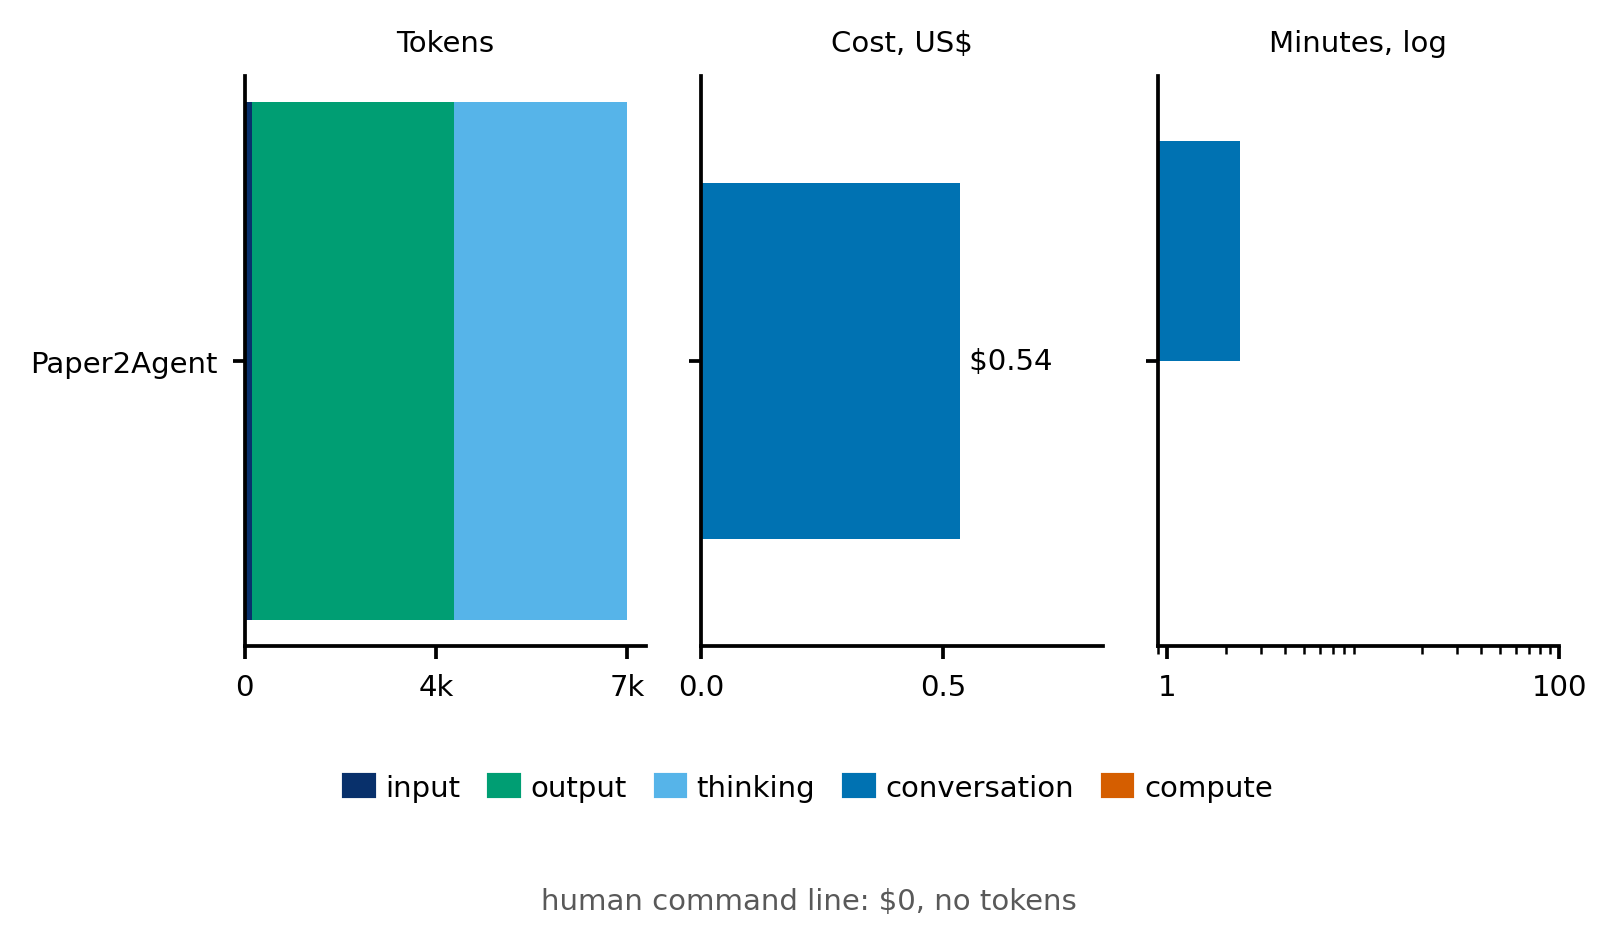

In [3]:
# scripts/paper/make_cost_panel.py, inlined. sys.argv is what the paper passes it.
import sys
sys.argv = ['make_cost_panel.py', 'figure2', 'upstream_mcp_prompt']
__file__ = "../scripts/paper/make_cost_panel.py"

"""The agent's cost, as a chart rather than a table.

Requirement R4: cost is drawn, not tabulated. Three things a reader needs, side by side:
where the tokens went, what each run cost, and how the conversation time compares with the
compute it set off. The last one is the point: a minute of talking buys hours of GPU.

Usage: 51_make_cost_panel.py <figure2|figure3> <run_id> [run_id ...]
       run ids are the keys in cost/agent_runs.csv
"""
from __future__ import annotations

import csv
import json
import sys
import os
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib import font_manager

sys.path.insert(0, str(Path(__file__).resolve().parent))
import panel_style

RUN = Path(os.environ.get("LV_RUN", "/project2/sli68423_1316/projects/long_verse/results/2026_09_25_longverse_agent_benchmark"))
FONT_DIR = Path(os.environ.get("LV_FONTS", "/project2/sli68423_1316/users/yang/software/fonts"))
FONT_USED = "DejaVu Sans"
for t in ("arial.ttf", "arialbd.ttf"):
    if (FONT_DIR / t).is_file():
        font_manager.fontManager.addfont(str(FONT_DIR / t))
if (FONT_DIR / "arial.ttf").is_file():
    FONT_USED = "Arial"
panel_style.apply(plt, FONT_USED)
# "input" and "conversation" shared one blue in a single legend, which reads as the same
# category listed twice; input is now a darker navy that no other series uses
C_IN, C_OUT, C_THINK, C_CACHE = "#08306B", "#009E73", "#56B4E9", "#BBBBBB"
AGENT_C, HUMAN_C = "#0072B2", "#D55E00"


def main() -> int:
    if len(sys.argv) < 3:
        print(__doc__.strip().splitlines()[-2], file=sys.stderr)
        return 2
    which, want = sys.argv[1], sys.argv[2:]
    rows = {r["run_id"]: r for r in csv.DictReader(open(RUN / "cost" / "agent_runs.csv"))}
    runs = [rows[w] for w in want if w in rows]
    if not runs:
        print(f"none of {want} in cost/agent_runs.csv; run 32_agent_cost_ledger.py first",
              file=sys.stderr)
        return 1
    out = RUN / which / "panels"; out.mkdir(parents=True, exist_ok=True)
    src = RUN / which / "source_data"; src.mkdir(parents=True, exist_ok=True)
    # "tools_only" on its own was read as the command line arm, which it is not: all three
    # of these are the agent, differing only in how much it is told. The human arm types a
    # command and spends no tokens at all, so it has no bar here and is stated instead.
    # Named for what the agent was given, not for the switch in the harness. "Paper2Agent
    # MCP" was considered and rejected: Paper2Agent is another group's system, and labelling
    # an arm with it invites the reader to think that system was run here. What was run is
    # this project's own MCP server; only the prompt layer follows the Paper2Agent design,
    # and that belongs in the text rather than on an axis.
    # Two arms, two labels, both short enough for an axis:
    #   MCP           this project's MCP server, tools attached and nothing else said
    #   Paper2Agent   the same server with its own prompt surfaced, which is the pattern
    #                 the Paper2Agent paper describes
    # The label names a design, not a piece of software that was executed here. Nothing of
    # Paper2Agent's own code was run, so the figure caption says so in words; putting that
    # qualification on the axis would make the axis unreadable.
    PRETTY = {
        "tools_only":  "MCP",
        "with_prompt": "MCP\n+ inspect hint",
        "mcp_prompt":  "Paper2Agent",
    }
    names = [PRETTY.get(r["run_id"].replace("upstream_", "").replace("phasing_", ""),
                        r["run_id"]) for r in runs]
    x = range(len(runs))

    # Drawn at the size it is placed at in the deck, 5.9 x 1.85 inches, rather than at a
    # comfortable size and shrunk afterwards. Shrinking a 7.4 inch figure into 3.9 inches
    # of slide scaled its 8 pt labels down to about 4 pt, which is where the tick labels
    # started running into the bars.
    # Horizontal bars, because at 12 pt the arm names will not fit under a vertical bar:
    # "MCP" and "Paper2Agent" collided into each other at every width tried. On the y axis
    # they have the whole row. Only the leftmost panel carries the names, the legend sits
    # below all three in one line, and the tick labels are shortened, because a 12 pt floor
    # in a 5.4 inch strip pays for itself in removed content, not in smaller type.
    fig, axes = plt.subplots(1, 3, figsize=(5.4, 2.45), sharey=True)
    yy = list(range(len(runs)))[::-1]

    def short(v):
        return f"{v/1000:.0f}k" if v >= 1000 else f"{v:.0f}"

    ax = axes[0]
    ins = [int(r["input_tokens"]) for r in runs]
    outs = [int(r["output_tokens"]) for r in runs]
    thinks = [int(r["thinking_tokens"]) for r in runs]
    vis = [o - t for o, t in zip(outs, thinks)]
    ax.barh(yy, ins, color=C_IN, label="input")
    ax.barh(yy, vis, left=ins, color=C_OUT, label="output")
    ax.barh(yy, thinks, left=[i + v for i, v in zip(ins, vis)], color=C_THINK,
            label="thinking")
    ax.set_yticks(yy); ax.set_yticklabels(names)
    ax.set_title("Tokens")
    hi = max(i + o for i, o in zip(ins, outs))
    ax.set_xticks([0, hi / 2, hi])
    ax.set_xticklabels(["0", short(hi / 2), short(hi)])

    ax = axes[1]
    costs = [float(r["cost_usd"]) for r in runs]
    ax.barh(yy, costs, color=AGENT_C, height=0.55)
    for y_, c in zip(yy, costs):
        ax.text(c, y_, f" ${c:.2f}", va="center", ha="left", fontsize=panel_style.MIN_PT)
    ax.set_title("Cost, US$")
    ax.set_xlim(0, max(costs) * 1.55)
    ax.set_xticks([0, round(max(costs), 1)])

    ax = axes[2]
    talk = [float(r["wall_seconds"]) / 60 for r in runs]
    meta = json.loads((RUN / which / "compute_minutes.json").read_text()) \
        if (RUN / which / "compute_minutes.json").is_file() else {}
    comp = [meta.get(r["run_id"], 0) for r in runs]
    h = 0.34
    ax.barh([y_ + h / 2 for y_ in yy], talk, height=h, color=AGENT_C, label="conversation")
    if any(comp):
        ax.barh([y_ - h / 2 for y_ in yy], comp, height=h, color=HUMAN_C, label="compute")
    ax.set_xscale("log")
    ax.set_title("Minutes, log")
    ax.set_xticks([1, 100])
    ax.set_xticklabels(["1", "100"])

    handles = [Patch(color=C_IN, label="input"), Patch(color=C_OUT, label="output"),
               Patch(color=C_THINK, label="thinking"),
               Patch(color=AGENT_C, label="conversation"), Patch(color=HUMAN_C, label="compute")]
    fig.legend(handles=handles, loc="lower center", ncol=5, frameon=False,
               fontsize=panel_style.MIN_PT, bbox_to_anchor=(0.5, -0.13),
               handlelength=1.0, handletextpad=0.4, columnspacing=1.0)
    fig.text(0.5, -0.24, "human command line: $0, no tokens", ha="center",
             fontsize=panel_style.MIN_PT, color="0.35")

    fig.tight_layout()
    for e in ("pdf", "png"):
        fig.savefig(out / f"panel_agent_cost.{e}")
    plt.close(fig)

    with open(src / "panel_agent_cost.csv", "w", newline="") as fh:
        w2 = csv.DictWriter(fh, fieldnames=list(runs[0]))
        w2.writeheader(); w2.writerows(runs)
    print(f"font: {FONT_USED}")
    for r, c in zip(runs, comp):
        print(f"  {r['run_id']:<26} ${r['cost_usd']:>7}  talk {float(r['wall_seconds'])/60:5.1f} min"
              f"  compute {c:6.1f} min  in {r['input_tokens']:>5} out {r['output_tokens']:>6}")
    print(f"panel -> {out/'panel_agent_cost.png'}")
    return 0

main()
print(harvest('ed1_calling'), "panels collected")
show("panel_agent_cost.png", prefix='ed1_calling')

## b - the same for the phasing run

font: DejaVu Sans
  phasing_mcp_prompt         $ 0.2237  talk   1.0 min  compute    0.0 min  in    60 out   3362
panel -> ./data/runs/figure3/panels/panel_agent_cost.png
2 panels collected


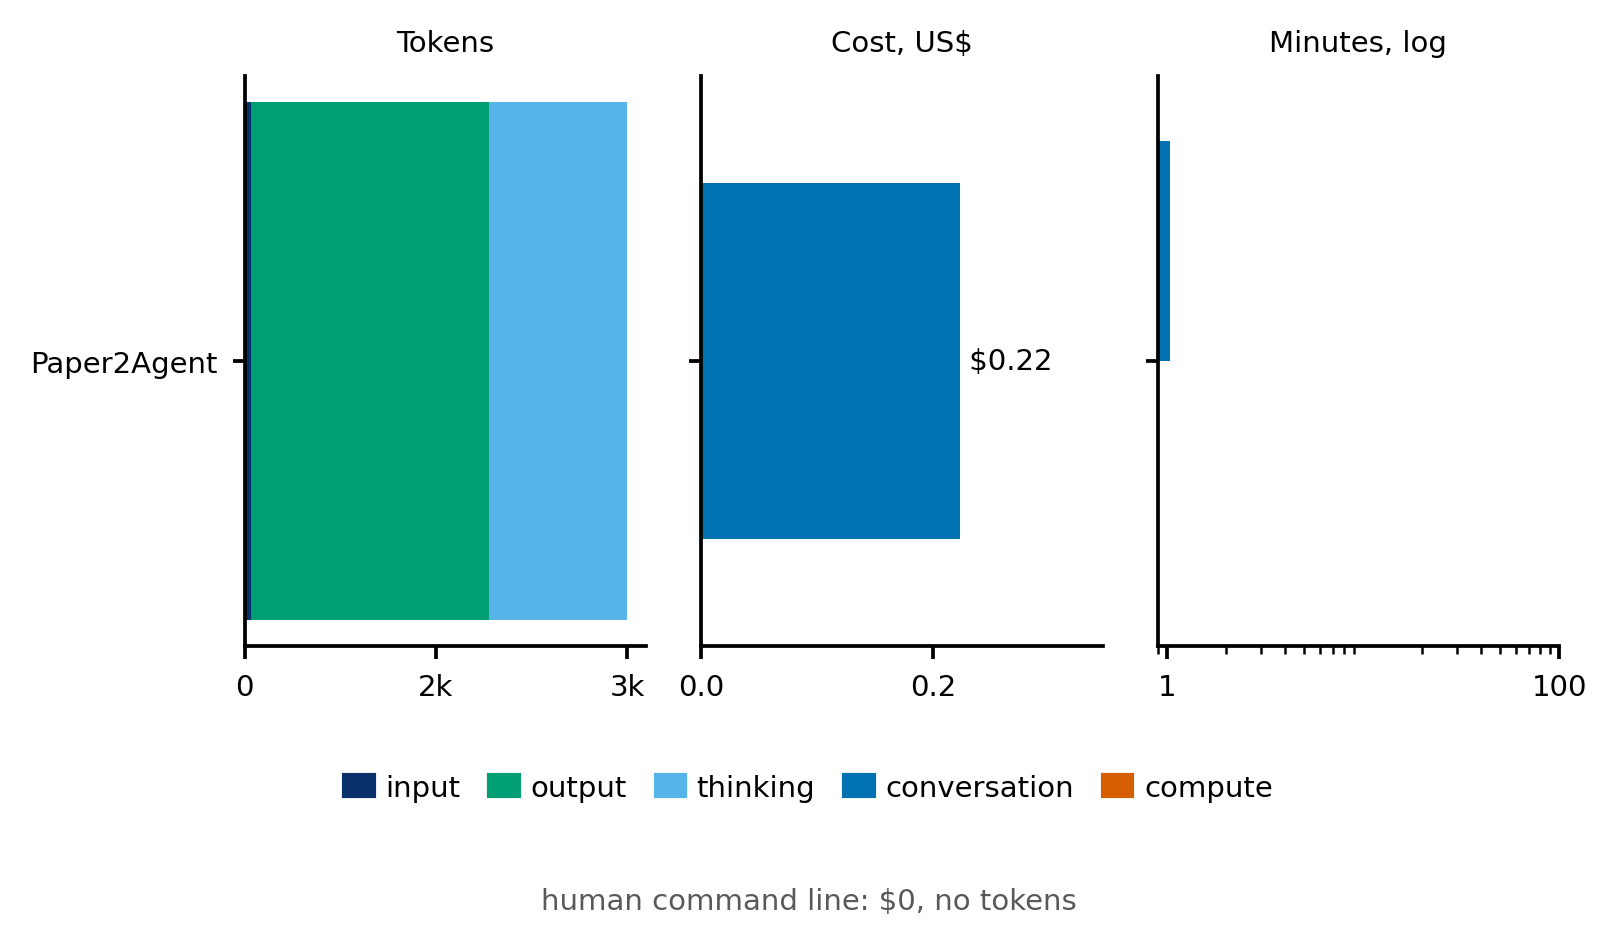

In [4]:
# scripts/paper/make_cost_panel.py, inlined. sys.argv is what the paper passes it.
import sys
sys.argv = ['make_cost_panel.py', 'figure3', 'phasing_mcp_prompt']
__file__ = "../scripts/paper/make_cost_panel.py"

"""The agent's cost, as a chart rather than a table.

Requirement R4: cost is drawn, not tabulated. Three things a reader needs, side by side:
where the tokens went, what each run cost, and how the conversation time compares with the
compute it set off. The last one is the point: a minute of talking buys hours of GPU.

Usage: 51_make_cost_panel.py <figure2|figure3> <run_id> [run_id ...]
       run ids are the keys in cost/agent_runs.csv
"""
from __future__ import annotations

import csv
import json
import sys
import os
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib import font_manager

sys.path.insert(0, str(Path(__file__).resolve().parent))
import panel_style

RUN = Path(os.environ.get("LV_RUN", "/project2/sli68423_1316/projects/long_verse/results/2026_09_25_longverse_agent_benchmark"))
FONT_DIR = Path(os.environ.get("LV_FONTS", "/project2/sli68423_1316/users/yang/software/fonts"))
FONT_USED = "DejaVu Sans"
for t in ("arial.ttf", "arialbd.ttf"):
    if (FONT_DIR / t).is_file():
        font_manager.fontManager.addfont(str(FONT_DIR / t))
if (FONT_DIR / "arial.ttf").is_file():
    FONT_USED = "Arial"
panel_style.apply(plt, FONT_USED)
# "input" and "conversation" shared one blue in a single legend, which reads as the same
# category listed twice; input is now a darker navy that no other series uses
C_IN, C_OUT, C_THINK, C_CACHE = "#08306B", "#009E73", "#56B4E9", "#BBBBBB"
AGENT_C, HUMAN_C = "#0072B2", "#D55E00"


def main() -> int:
    if len(sys.argv) < 3:
        print(__doc__.strip().splitlines()[-2], file=sys.stderr)
        return 2
    which, want = sys.argv[1], sys.argv[2:]
    rows = {r["run_id"]: r for r in csv.DictReader(open(RUN / "cost" / "agent_runs.csv"))}
    runs = [rows[w] for w in want if w in rows]
    if not runs:
        print(f"none of {want} in cost/agent_runs.csv; run 32_agent_cost_ledger.py first",
              file=sys.stderr)
        return 1
    out = RUN / which / "panels"; out.mkdir(parents=True, exist_ok=True)
    src = RUN / which / "source_data"; src.mkdir(parents=True, exist_ok=True)
    # "tools_only" on its own was read as the command line arm, which it is not: all three
    # of these are the agent, differing only in how much it is told. The human arm types a
    # command and spends no tokens at all, so it has no bar here and is stated instead.
    # Named for what the agent was given, not for the switch in the harness. "Paper2Agent
    # MCP" was considered and rejected: Paper2Agent is another group's system, and labelling
    # an arm with it invites the reader to think that system was run here. What was run is
    # this project's own MCP server; only the prompt layer follows the Paper2Agent design,
    # and that belongs in the text rather than on an axis.
    # Two arms, two labels, both short enough for an axis:
    #   MCP           this project's MCP server, tools attached and nothing else said
    #   Paper2Agent   the same server with its own prompt surfaced, which is the pattern
    #                 the Paper2Agent paper describes
    # The label names a design, not a piece of software that was executed here. Nothing of
    # Paper2Agent's own code was run, so the figure caption says so in words; putting that
    # qualification on the axis would make the axis unreadable.
    PRETTY = {
        "tools_only":  "MCP",
        "with_prompt": "MCP\n+ inspect hint",
        "mcp_prompt":  "Paper2Agent",
    }
    names = [PRETTY.get(r["run_id"].replace("upstream_", "").replace("phasing_", ""),
                        r["run_id"]) for r in runs]
    x = range(len(runs))

    # Drawn at the size it is placed at in the deck, 5.9 x 1.85 inches, rather than at a
    # comfortable size and shrunk afterwards. Shrinking a 7.4 inch figure into 3.9 inches
    # of slide scaled its 8 pt labels down to about 4 pt, which is where the tick labels
    # started running into the bars.
    # Horizontal bars, because at 12 pt the arm names will not fit under a vertical bar:
    # "MCP" and "Paper2Agent" collided into each other at every width tried. On the y axis
    # they have the whole row. Only the leftmost panel carries the names, the legend sits
    # below all three in one line, and the tick labels are shortened, because a 12 pt floor
    # in a 5.4 inch strip pays for itself in removed content, not in smaller type.
    fig, axes = plt.subplots(1, 3, figsize=(5.4, 2.45), sharey=True)
    yy = list(range(len(runs)))[::-1]

    def short(v):
        return f"{v/1000:.0f}k" if v >= 1000 else f"{v:.0f}"

    ax = axes[0]
    ins = [int(r["input_tokens"]) for r in runs]
    outs = [int(r["output_tokens"]) for r in runs]
    thinks = [int(r["thinking_tokens"]) for r in runs]
    vis = [o - t for o, t in zip(outs, thinks)]
    ax.barh(yy, ins, color=C_IN, label="input")
    ax.barh(yy, vis, left=ins, color=C_OUT, label="output")
    ax.barh(yy, thinks, left=[i + v for i, v in zip(ins, vis)], color=C_THINK,
            label="thinking")
    ax.set_yticks(yy); ax.set_yticklabels(names)
    ax.set_title("Tokens")
    hi = max(i + o for i, o in zip(ins, outs))
    ax.set_xticks([0, hi / 2, hi])
    ax.set_xticklabels(["0", short(hi / 2), short(hi)])

    ax = axes[1]
    costs = [float(r["cost_usd"]) for r in runs]
    ax.barh(yy, costs, color=AGENT_C, height=0.55)
    for y_, c in zip(yy, costs):
        ax.text(c, y_, f" ${c:.2f}", va="center", ha="left", fontsize=panel_style.MIN_PT)
    ax.set_title("Cost, US$")
    ax.set_xlim(0, max(costs) * 1.55)
    ax.set_xticks([0, round(max(costs), 1)])

    ax = axes[2]
    talk = [float(r["wall_seconds"]) / 60 for r in runs]
    meta = json.loads((RUN / which / "compute_minutes.json").read_text()) \
        if (RUN / which / "compute_minutes.json").is_file() else {}
    comp = [meta.get(r["run_id"], 0) for r in runs]
    h = 0.34
    ax.barh([y_ + h / 2 for y_ in yy], talk, height=h, color=AGENT_C, label="conversation")
    if any(comp):
        ax.barh([y_ - h / 2 for y_ in yy], comp, height=h, color=HUMAN_C, label="compute")
    ax.set_xscale("log")
    ax.set_title("Minutes, log")
    ax.set_xticks([1, 100])
    ax.set_xticklabels(["1", "100"])

    handles = [Patch(color=C_IN, label="input"), Patch(color=C_OUT, label="output"),
               Patch(color=C_THINK, label="thinking"),
               Patch(color=AGENT_C, label="conversation"), Patch(color=HUMAN_C, label="compute")]
    fig.legend(handles=handles, loc="lower center", ncol=5, frameon=False,
               fontsize=panel_style.MIN_PT, bbox_to_anchor=(0.5, -0.13),
               handlelength=1.0, handletextpad=0.4, columnspacing=1.0)
    fig.text(0.5, -0.24, "human command line: $0, no tokens", ha="center",
             fontsize=panel_style.MIN_PT, color="0.35")

    fig.tight_layout()
    for e in ("pdf", "png"):
        fig.savefig(out / f"panel_agent_cost.{e}")
    plt.close(fig)

    with open(src / "panel_agent_cost.csv", "w", newline="") as fh:
        w2 = csv.DictWriter(fh, fieldnames=list(runs[0]))
        w2.writeheader(); w2.writerows(runs)
    print(f"font: {FONT_USED}")
    for r, c in zip(runs, comp):
        print(f"  {r['run_id']:<26} ${r['cost_usd']:>7}  talk {float(r['wall_seconds'])/60:5.1f} min"
              f"  compute {c:6.1f} min  in {r['input_tokens']:>5} out {r['output_tokens']:>6}")
    print(f"panel -> {out/'panel_agent_cost.png'}")
    return 0

main()
print(harvest('ed1_phasing'), "panels collected")
show("panel_agent_cost.png", prefix='ed1_phasing')